### **Problem Statement**

Classification problem - text analytics

Kotzias,Dimitrios. (2015). Sentiment Labelled Sentences. UCI Machine Learning Repository. https://doi.org/10.24432/C57604.



### **Setting up Spark environment variables and installing dependencies**

In [ ]:
# Importing the OS module
import os

# Setting up Spark environment variable  - Install OpenJDK environment to run spark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# Downloading Apache Spark 3.5.0 with Hadoop quietly
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

# Extract the Spark Package
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Set JAVA_HOME environment path pointing to where OpenJDK is installed
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Set SPARK_HOME environment path pointing to where Spark is installed
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

In [ ]:
# Lists files and directories in current working directory

!ls

sample_data  spark-3.5.0-bin-hadoop3  spark-3.5.0-bin-hadoop3.tgz


In [ ]:
# Installing the findspark package - necessary to run spark from Jupyter Notebook
!pip install findspark

# Importing the findspark library
import findspark

# Initializing PySpark - locates Spark installation
findspark.init()

### **A higher level and a slightly more straight forward approach for Spark installation**

In [ ]:
# !pip install pyspark

In [ ]:
# Installing pytictoc for monitoring time elapsed during code execution

!pip install pytictoc --quiet

In [ ]:
!pip install xgboost --quiet

### **Importing dependencies**

In [ ]:
# Importing SparkSession from pyspark.sql, to create Spark entry points.
from pyspark.sql import SparkSession


In [ ]:
# Importing pandas for data preprocessing
import pandas as pd

# Library for advanced data visualization

import seaborn as sns

# Libraries for Data preprocessing and Data Cleaning
from pyspark.sql import functions as F

from pyspark.sql.types import DoubleType

from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, HashingTF, IDF

# Libraries for the Classification Model

from pyspark.ml.classification import LogisticRegression

from pyspark.ml import Pipeline

from pyspark.ml.evaluation import BinaryClassificationEvaluator

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [ ]:
# Importing TicToc class from pytictoc for the timing functionality
from pytictoc import TicToc

In [ ]:
# Calling the builder method and getOrCreate to create or
# retrieving a SparkSession
# spark runs locally with available cores


spark =  SparkSession.builder \
         .master("local[*]") \
         .appName("Spark text analytics") \
         .getOrCreate()

In [ ]:
spark

### **Importing the dataset**

In [ ]:
# Dependencies to import required files from google drive to google - colab environment
from google.colab import drive

In [ ]:

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing the dataset labelled_1.txt, labelled_2.txt, labelled_3.txt
# using spark.read.text()

df_1 = spark.read.text("/content/drive/MyDrive/labelled_1.txt", lineSep = "\n")
df_2 = spark.read.text("/content/drive/MyDrive/labelled_2.txt", lineSep = "\n")
df_3 = spark.read.text("/content/drive/MyDrive/labelled_3.txt", lineSep = "\n")


In [ ]:
# Using toDF() function to provide column name "Text"

col_name = ["Text"]
df_a = df_1.toDF(*col_name)
df_b = df_2.toDF(*col_name)
df_c = df_3.toDF(*col_name)

In [ ]:
# Display the first five rows of the dataframe df_a

df_a.show(n = 5, truncate = False)

+-------------------------------------------------------------------------------------+
|Text                                                                                 |
+-------------------------------------------------------------------------------------+
|So there is no way for me to plug it in here in the US unless I go by a converter.\t0|
|Good case, Excellent value.\t1                                                       |
|Great for the jawbone.\t1                                                            |
|Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!\t0   |
|The mic is great.\t1                                                                 |
+-------------------------------------------------------------------------------------+
only showing top 5 rows



In [ ]:
# Display the first five rows of the dataframe df_b on movie reviews
df_b.show(n = 5, truncate = False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Text                                                                                                                                                                                           |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|A very, very, very slow-moving, aimless movie about a distressed, drifting young man.  \t0                                                                                                     |
|Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.  \t0                                                                                         |
|Attempting artiness with blac

In [ ]:
## Display the first five rows of the dataframe df_c

df_c.show(n = 5, truncate = False)

+------------------------------------------------------------------------------------------+
|Text                                                                                      |
+------------------------------------------------------------------------------------------+
|Wow... Loved this place.\t1                                                               |
|Crust is not good.\t0                                                                     |
|Not tasty and the texture was just nasty.\t0                                              |
|Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.\t1|
|The selection on the menu was great and so were the prices.\t1                            |
+------------------------------------------------------------------------------------------+
only showing top 5 rows



In [ ]:
# Print the schema of the dataframe in a tree format using df.printSchema() method

df_a.printSchema()

root
 |-- Text: string (nullable = true)



In [ ]:
# Split the dataframe string column - text is in one column and the review score is
# in the second column

split_col1 =F.split(df_a['Text'], "\t")
split_col2 = F.split(df_b['Text'], "\t")
split_col3 = F.split(df_c['Text'], "\t")

In [ ]:
# Using .withColumn() and getItem() to retrieve each part(text and review score )
# as separate columns

df_u = (
    df_a
    .withColumn('Review',split_col1.getItem(0))
    .withColumn('Score',split_col1.getItem(1))
    .drop('Text')
)

df_u.show(n = 5, truncate  = False)


+----------------------------------------------------------------------------------+-----+
|Review                                                                            |Score|
+----------------------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|0    |
|Good case, Excellent value.                                                       |1    |
|Great for the jawbone.                                                            |1    |
|Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   |0    |
|The mic is great.                                                                 |1    |
+----------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [ ]:
# # Using .withColumn() and getItem() to retrieve each part(text and review score )
# as separate columns

df_v = (
    df_b
    .withColumn('Review', split_col2.getItem(0))
    .withColumn('Score', split_col2.getItem(1))
    .drop('Text')
)

df_v.show(n = 5, truncate = False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Review                                                                                                                                                                                      |Score|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|A very, very, very slow-moving, aimless movie about a distressed, drifting young man.                                                                                                       |0    |
|Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.                                                                                           |0    |
|Attempting art

In [ ]:
# Using .withColumn() and getItem() to retrieve each part(text and review score)
# as separate columns

df_w = (
    df_c
    .withColumn('Review', split_col3.getItem(0))
    .withColumn('Score', split_col3.getItem(1))
    .drop('Text')
)

df_w.show(n = 5, truncate = False)

+---------------------------------------------------------------------------------------+-----+
|Review                                                                                 |Score|
+---------------------------------------------------------------------------------------+-----+
|Wow... Loved this place.                                                               |1    |
|Crust is not good.                                                                     |0    |
|Not tasty and the texture was just nasty.                                              |0    |
|Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.|1    |
|The selection on the menu was great and so were the prices.                            |1    |
+---------------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [ ]:
# Combining the dataframe  : using the union()

df = df_u.union(df_v)


In [ ]:
# Combining the dataframe  : using the union()

df = df.union(df_w)


In [ ]:
# Display the first five rows of the combined dataframe

df.show(n = 5, truncate = False)

+----------------------------------------------------------------------------------+-----+
|Review                                                                            |Score|
+----------------------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|0    |
|Good case, Excellent value.                                                       |1    |
|Great for the jawbone.                                                            |1    |
|Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   |0    |
|The mic is great.                                                                 |1    |
+----------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [ ]:
# Using withColumn() and cast() for the Score column of the dataframe to be of
# DoubleType()

df = df.withColumn("Score",df.Score.cast(DoubleType()))

In [ ]:
# Display the number of rows and columns in the DataFrame

print("Shape of the dataframe:",(df.count(), len(df.columns)))

Shape of the dataframe: (3000, 2)


In [ ]:
# Datatype of each column of the dataframe using df.dtypes attribute

df.dtypes

[('Review', 'string'), ('Score', 'double')]

### **Conversion of Spark DataFrame to a Pandas Dataframe**


In [ ]:
# Convert the Spark DataFrame to a Pandas Dataframe using toPandas() method

df_pandas = df.toPandas()

df_pandas['Score'].unique()

array([0., 1.])

In [ ]:
# proportion of positive and negative reviews

df_pandas['Score'].value_counts(normalize=True)

0.0    0.5
1.0    0.5
Name: Score, dtype: float64

<Axes: xlabel='Score', ylabel='count'>

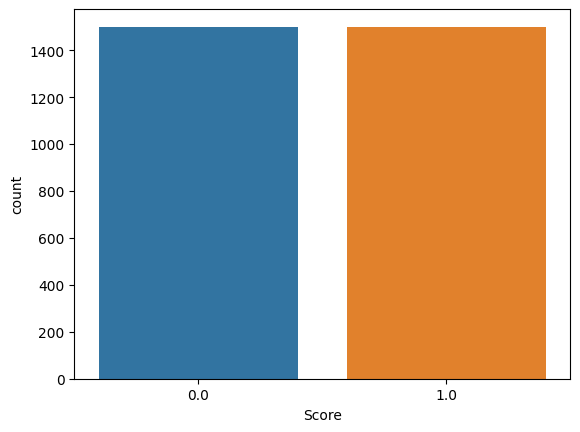

In [ ]:
# Visualization of the Score column of the dataframe using Seaborn count plot

sns.countplot(data = df_pandas, x = "Score")

### **Clean the text reviews with Regular-Expression Tokenizer**

In [ ]:
# Using RegexTokenizer() for creating a dataframe column with the tokens

tokenizer = RegexTokenizer(inputCol = "Review",
                           outputCol = "Tokens",
                           pattern = "\\W")

In [ ]:
# Using .transform() method for tokenization

df_1 = tokenizer.transform(df)

In [ ]:
#
df_1.show(n=5, truncate = False)

+----------------------------------------------------------------------------------+-----+-------------------------------------------------------------------------------------------------------+
|Review                                                                            |Score|Tokens                                                                                                 |
+----------------------------------------------------------------------------------+-----+-------------------------------------------------------------------------------------------------------+
|So there is no way for me to plug it in here in the US unless I go by a converter.|0.0  |[so, there, is, no, way, for, me, to, plug, it, in, here, in, the, us, unless, i, go, by, a, converter]|
|Good case, Excellent value.                                                       |1.0  |[good, case, excellent, value]                                                                         |
|Great for the jawbone.  

### **Exclude Stop Words**

In [ ]:
# Removing Stop words from the dataframe column : Tokens using StopWordsRemover

stopwordsRemoved = StopWordsRemover(inputCol = "Tokens",
                                    outputCol = "Filtered")

In [ ]:
# Use of .transform() method for data cleaning and removing stop words

df_1 = stopwordsRemoved.transform(df_1)

In [ ]:
# Display the first five rows of the dataframe columns : Review, Filtered and Score

df_1.select(['Review','Filtered','Score']).show(n=5, truncate = False)

+----------------------------------------------------------------------------------+---------------------------------------------------------------------+-----+
|Review                                                                            |Filtered                                                             |Score|
+----------------------------------------------------------------------------------+---------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|[way, plug, us, unless, go, converter]                               |0.0  |
|Good case, Excellent value.                                                       |[good, case, excellent, value]                                       |1.0  |
|Great for the jawbone.                                                            |[great, jawbone]                                                     |1.0  |
|Tied to charger for conversations

### **Hashing TF**

In [ ]:
# Creating a hashingTF instance, transforms the tokens in the Filtered Column
# in a new column "Raw_features"

hashing_TF = HashingTF(inputCol = "Filtered",
                       outputCol = "Raw_features",
                       numFeatures = 10000)

# Applying HashingTF to the dataframe df_1 using the transform() method

featurized_data = hashing_TF.transform(df_1)


### **Inverse Document Frequency**

In [ ]:
# Create an IDF instance with the inputCol : "Raw_features", outputCol: "features"
# IDF reflects the importance of each word to a document in a collection

idf = IDF(inputCol = "Raw_features",
          outputCol = "features")

# Fit the idf to the 'featurized_data' where the IDF model learns the inverse
# document frequency of each word or feature

idf_vectorizer = idf.fit(featurized_data)

# Using the transform() method on the featurized data, applying the IDF weights
# 'Raw_features' and creates a dataframe scaled_df with the 'features' column
# consisting of feature vectors

scaled_df = idf_vectorizer.transform(featurized_data)


In [ ]:
# The resulting DataFrame shows the transformed features, alongside the
# original text ('Review') and the 'score'

scaled_df.select(['Review','features','Score']).show(n=5, truncate = False)

scaled_df.dtypes

+----------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Review                                                                            |features                                                                                                                                                                                          |Score|
+----------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|(10000,[6451,6660,7788,8378,9391,9785],[3.8170461034139413

[('Review', 'string'),
 ('Score', 'double'),
 ('Tokens', 'array<string>'),
 ('Filtered', 'array<string>'),
 ('Raw_features', 'vector'),
 ('features', 'vector')]

### **Train-Test split**

In [ ]:
# Split the dataset into train and test datasets : 80% for the training dataset
# 20% for the test dataset

(train, test) = scaled_df.randomSplit([0.8, 0.2], 42)

### **Logistic Regression**

In [ ]:
# Initializing LogisticRegression with the features column, label column
# providing regularization parameter to be 0.3

lr = LogisticRegression(
    featuresCol="features",
    labelCol = "Score",
    family = 'binomial',
    regParam = 500,
    elasticNetParam = 0,
    maxIter = 50)

In [ ]:
# training the model (on the training dataset) with .fit() method

lr_model = lr.fit(train)

In [ ]:
# Making Predictions on the training dataset

predictions_1 = lr_model.transform(train)
predictions_1

DataFrame[Review: string, Score: double, Tokens: array<string>, Filtered: array<string>, Raw_features: vector, features: vector, rawPrediction: vector, probability: vector, prediction: double]

In [ ]:
# Making Predictions on the test dataset

predictions = lr_model.transform(test)
predictions

DataFrame[Review: string, Score: double, Tokens: array<string>, Filtered: array<string>, Raw_features: vector, features: vector, rawPrediction: vector, probability: vector, prediction: double]

In [ ]:
# Display the first five columns of predictions dataframe

predictions.select("Review", "probability", "prediction", "Score").show(n=5, truncate = False)

+------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+----------+-----+
|Review                                                                                                                        |probability                             |prediction|Score|
+------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+----------+-----+
|$50 Down the drain.                                                                                                           |[0.5000775315563168,0.49992246844368315]|0.0       |0.0  |
|.... Item arrived quickly and works great with my Metro PCS Samsung SCH-r450 slider phone and Sony Premium Sound in ear plugs.|[0.49878918081144247,0.5012108191885576]|1.0       |1.0  |
|2 thumbs up to this seller                                      

### **Evaluator**

training dataset

In [ ]:
evaluator = BinaryClassificationEvaluator(rawPredictionCol = "prediction", labelCol = "Score",metricName = "areaUnderROC")

In [ ]:
Predictionandlabel = predictions_1.select("Score","prediction")

In [ ]:
evaluator.evaluate(Predictionandlabel)

0.8937687435280195

In [ ]:
Predictionandlabel = predictions.select("Score","prediction")

In [ ]:
evaluator.evaluate(Predictionandlabel)

0.7329308591764108

In [ ]:
Predictionandlabel.show(n=5)

+-----+----------+
|Score|prediction|
+-----+----------+
|  0.0|       0.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows

